In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 29.9 MB/s eta 0:00:00


In [3]:
# Import Libraries
import os
import json
import csv
from pathlib import Path

import cv2
import easyocr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [4]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing"
)

# Preprocessed images
PREPROCESSED_PATH = PROJECT_ROOT / "outputs" / "preprocessed"

# OCR output
OCR_OUTPUT_PATH = PROJECT_ROOT / "outputs" / "ocr"

# Document folders
INVOICE_PATH = PREPROCESSED_PATH / "invoices"
RESUME_PATH = PREPROCESSED_PATH / "resumes"
ID_CARD_PATH = PREPROCESSED_PATH / "id_cards"

In [5]:
for folder in [
    OCR_OUTPUT_PATH / "invoices",
    OCR_OUTPUT_PATH / "resumes",
    OCR_OUTPUT_PATH / "id_cards"
]:
    folder.mkdir(parents=True, exist_ok=True)

print("OCR directories ready.")

OCR directories ready.


In [6]:
def get_image_files(folder):
    """
    Return supported image files from a folder.
    """

    folder = Path(folder)

    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }

    return sorted([
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in extensions
    ])

In [7]:
invoice_files = get_image_files(INVOICE_PATH)
resume_files = get_image_files(RESUME_PATH)
id_card_files = get_image_files(ID_CARD_PATH)

print("Invoices :", len(invoice_files))
print("Resumes  :", len(resume_files))
print("ID Cards :", len(id_card_files))

Invoices : 778
Resumes  : 96
ID Cards : 1852


In [8]:
# Development Mode

MAX_FILES = 3

In [9]:
invoice_test_files = invoice_files[:MAX_FILES]
resume_test_files = resume_files[:MAX_FILES]
id_card_test_files = id_card_files[:MAX_FILES]

print("Development samples:")
print("Invoices :", len(invoice_test_files))
print("Resumes  :", len(resume_test_files))
print("ID Cards :", len(id_card_test_files))

Development samples:
Invoices : 3
Resumes  : 3
ID Cards : 3


In [10]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [11]:
print("EasyOCR reader initialized successfully.")

EasyOCR reader initialized successfully.


In [12]:
def extract_ocr_results(image_path, confidence_threshold=0.30):
    """
    Extract text, confidence scores and bounding boxes
    from an image using EasyOCR.

    Parameters
    ----------
    image_path : str or Path
        Path to image.

    confidence_threshold : float
        Minimum confidence required.

    Returns
    -------
    list
        OCR detection results.
    """

    image_path = str(image_path)

    results = reader.readtext(
        image_path,
        detail=1,
        paragraph=False
    )

    extracted_results = []

    for bbox, text, confidence in results:

        if confidence >= confidence_threshold:

            extracted_results.append({
                "text": text,
                "confidence": float(confidence),
                "bbox": bbox
            })

    return extracted_results

In [13]:
# Create Text-Only Function

def extract_text(image_path, confidence_threshold=0.30):
    """
    Extract only recognized text.
    """

    results = extract_ocr_results(
        image_path,
        confidence_threshold
    )

    text = "\n".join(
        item["text"]
        for item in results
    )

    return text

In [15]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA available: True
GPU: Tesla T4


In [17]:
import easyocr

reader = easyocr.Reader(
    ['en'],
    gpu=torch.cuda.is_available(),
    verbose=False
)

print("EasyOCR reader initialized successfully.")

EasyOCR reader initialized successfully.


In [18]:
def extract_ocr_results(image_path, confidence_threshold=0.30):

    results = reader.readtext(
        str(image_path),
        detail=1,
        paragraph=False
    )

    extracted_results = []

    for bbox, text, confidence in results:

        if confidence >= confidence_threshold:

            extracted_results.append({
                "text": text,
                "confidence": float(confidence),
                "bbox": bbox
            })

    return extracted_results

In [19]:
sample_invoice = invoice_files[0]

print("Processing:", sample_invoice)

invoice_results = extract_ocr_results(
    sample_invoice
)

invoice_results

Processing: /content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed/invoices/X00016469612.jpg


[{'text': 'tan woon yann',
  'confidence': 0.9990357905021446,
  'bbox': [[np.int32(153), np.int32(58)],
   [np.int32(720), np.int32(58)],
   [np.int32(720), np.int32(149)],
   [np.int32(153), np.int32(149)]]},
 {'text': 'BOOK TA _K (TAMAN DAYA) SDN BHD',
  'confidence': 0.5796655546978505,
  'bbox': [[np.int32(154), np.int32(202)],
   [np.int32(934), np.int32(202)],
   [np.int32(934), np.int32(254)],
   [np.int32(154), np.int32(254)]]},
 {'text': '789H17-W',
  'confidence': 0.5969223617629142,
  'bbox': [[np.int32(455), np.int32(263)],
   [np.int32(637), np.int32(263)],
   [np.int32(637), np.int32(307)],
   [np.int32(455), np.int32(307)]]},
 {'text': 'NO.S: 55,57 & S9, JALAN SAGU I8,',
  'confidence': 0.3956013389394737,
  'bbox': [[np.int32(240), np.int32(314)],
   [np.int32(852), np.int32(314)],
   [np.int32(852), np.int32(368)],
   [np.int32(240), np.int32(368)]]},
 {'text': 'TAMAN DAYA,',
  'confidence': 0.5767062000094525,
  'bbox': [[np.int32(421), np.int32(369)],
   [np.int32(6

In [20]:
from pathlib import Path

INVOICE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed/invoices"
)

invoice_files = sorted([
    file for file in INVOICE_PATH.iterdir()
    if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("Number of invoices:", len(invoice_files))

Number of invoices: 778


In [21]:
sample_invoice = invoice_files[0]

invoice_results = extract_ocr_results(sample_invoice)

invoice_results

[{'text': 'tan woon yann',
  'confidence': 0.9990357905021446,
  'bbox': [[np.int32(153), np.int32(58)],
   [np.int32(720), np.int32(58)],
   [np.int32(720), np.int32(149)],
   [np.int32(153), np.int32(149)]]},
 {'text': 'BOOK TA _K (TAMAN DAYA) SDN BHD',
  'confidence': 0.5796655546978505,
  'bbox': [[np.int32(154), np.int32(202)],
   [np.int32(934), np.int32(202)],
   [np.int32(934), np.int32(254)],
   [np.int32(154), np.int32(254)]]},
 {'text': '789H17-W',
  'confidence': 0.5969223617629142,
  'bbox': [[np.int32(455), np.int32(263)],
   [np.int32(637), np.int32(263)],
   [np.int32(637), np.int32(307)],
   [np.int32(455), np.int32(307)]]},
 {'text': 'NO.S: 55,57 & S9, JALAN SAGU I8,',
  'confidence': 0.3956013389394737,
  'bbox': [[np.int32(240), np.int32(314)],
   [np.int32(852), np.int32(314)],
   [np.int32(852), np.int32(368)],
   [np.int32(240), np.int32(368)]]},
 {'text': 'TAMAN DAYA,',
  'confidence': 0.5767062000094525,
  'bbox': [[np.int32(421), np.int32(369)],
   [np.int32(6

In [22]:
invoice_text = extract_text(
    sample_invoice
)

print(invoice_text)

tan woon yann
BOOK TA _K (TAMAN DAYA) SDN BHD
789H17-W
NO.S: 55,57 & S9, JALAN SAGU I8,
TAMAN DAYA,
81100 JOIIOR BAHRU,
JOHOR
HHE
Dociinent No
Dale
25/12p2018 8: 13.39 PM
Cashier
MANIS
Menxler
CASH BILL
CODE/DESc
Disc
Abl( J J!l
QTY
Ri
RM
1 PC
9.00)
0,C0
9.00
Total
S
Rour :ling Acljustnienl;
0.00
Round:d Total (RM):
Cash
CHIANGE
0o
EXCH INNIGEABLE
# #ii i &
THANK YOU
PLEASE COI 'E AGATN


In [23]:
sample_resume = resume_files[0]

resume_text = extract_text(
    sample_resume
)

print(resume_text)

ELIZABETH COOPER
CLL CENTER MJAUAGER
EDUCATION
OBJECTIVE
EXPERIENCE
Hthschod
EXPERTISE
PERSONAL SKILLS
CERTIFICATION
OTHER SKILLS
14217
REFERENCE
Cop


In [24]:
# Test ONE ID Card

sample_id = id_card_files[0]

id_text = extract_text(
    sample_id
)

print(id_text)

NNCOHE TAXDEPAMHENT
GOVT OF NNDIA
MONIKA MAHADEV SHINDE
MAHADEv SHINDE
31/10/1992
Pcrmpnonk Accounl Numbcr
EJAPSO276M
Slgnaluro


In [25]:
# Display OCR Bounding Boxes

def visualize_ocr(
    image_path,
    confidence_threshold=0.30
):

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        raise FileNotFoundError(
            f"Cannot read image: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    results = extract_ocr_results(
        image_path,
        confidence_threshold
    )

    for item in results:

        bbox = np.array(
            item["bbox"],
            dtype=np.int32
        )

        cv2.polylines(
            image,
            [bbox],
            True,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(12, 10))

    plt.imshow(image)

    plt.axis("off")

    plt.title("OCR Text Detection")

    plt.show()

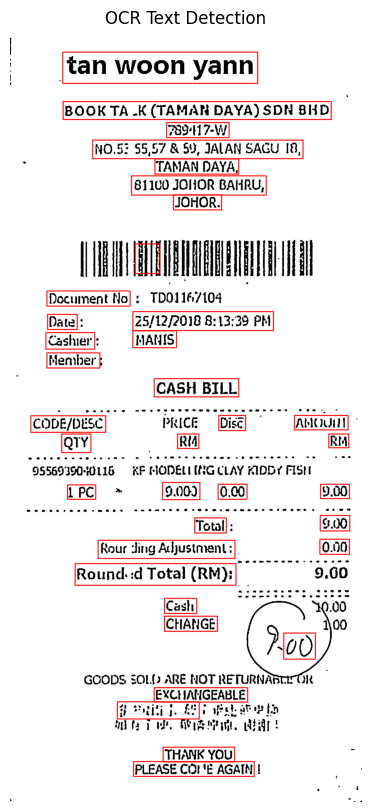

In [26]:
visualize_ocr(sample_invoice)

In [27]:
# Calculate Confidence

def calculate_average_confidence(results):

    if not results:
        return 0.0

    scores = [
        item["confidence"]
        for item in results
    ]

    return float(np.mean(scores))

In [28]:
invoice_confidence = calculate_average_confidence(
    invoice_results
)

print(
    f"Invoice OCR Confidence: "
    f"{invoice_confidence:.2%}"
)

Invoice OCR Confidence: 71.58%


In [29]:
# Fast Batch OCR

def batch_ocr(
    input_folder,
    max_files=3,
    confidence_threshold=0.30
):
    """
    Batch OCR.

    max_files=3 -> development mode
    max_files=None -> full dataset
    """

    image_files = get_image_files(
        input_folder
    )

    if max_files is not None:
        image_files = image_files[:max_files]

    documents = {}

    print(
        f"Processing {len(image_files)} images "
        f"from {Path(input_folder).name}"
    )

    for image_file in tqdm(
        image_files,
        desc=f"OCR - {Path(input_folder).name}"
    ):

        try:

            results = extract_ocr_results(
                image_file,
                confidence_threshold
            )

            text = "\n".join(
                item["text"]
                for item in results
            )

            confidence = (
                calculate_average_confidence(
                    results
                )
            )

            documents[image_file.name] = {
                "text": text,
                "detections": results,
                "average_confidence": confidence
            }

        except Exception as e:

            print(
                f"\nError: {image_file.name}"
            )

            print(e)

    return documents

In [30]:
invoice_text = batch_ocr(
    INVOICE_PATH,
    max_files=3
)

Processing 3 images from invoices


OCR - invoices:   0%|          | 0/3 [00:00<?, ?it/s]

In [31]:
resume_text = batch_ocr(
    RESUME_PATH,
    max_files=3
)

Processing 3 images from resumes


OCR - resumes:   0%|          | 0/3 [00:00<?, ?it/s]

In [32]:
id_text = batch_ocr(
    ID_CARD_PATH,
    max_files=3
)

Processing 3 images from id_cards


OCR - id_cards:   0%|          | 0/3 [00:00<?, ?it/s]

In [33]:
# Display Batch Results

for filename, result in invoice_text.items():

    print("=" * 70)

    print("FILE:", filename)

    print(
        "CONFIDENCE:",
        f"{result['average_confidence']:.2%}"
    )

    print()

    print(result["text"])

FILE: X00016469612.jpg
CONFIDENCE: 71.58%

tan woon yann
BOOK TA _K (TAMAN DAYA) SDN BHD
789H17-W
NO.S: 55,57 & S9, JALAN SAGU I8,
TAMAN DAYA,
81100 JOIIOR BAHRU,
JOHOR
HHE
Dociinent No
Dale
25/12p2018 8: 13.39 PM
Cashier
MANIS
Menxler
CASH BILL
CODE/DESc
Disc
Abl( J J!l
QTY
Ri
RM
1 PC
9.00)
0,C0
9.00
Total
S
Rour :ling Acljustnienl;
0.00
Round:d Total (RM):
Cash
CHIANGE
0o
EXCH INNIGEABLE
# #ii i &
THANK YOU
PLEASE COI 'E AGATN
FILE: X00016469620.jpg
CONFIDENCE: 76.16%

tan woon yann
(JOHOR )
SDH
BHD
(CO,REG :933109-X)
lot
1851-4
& 1851-8 _
JALAH KPB
6 ,
KaHASAN PERINDUSTRIAH BALAKOHG
43300   SERI
KEHBAHGAH
SELAHGOR
(MR
DIY TESCO TERBAU)
~IHVOICE -
ChoppihG BOARD 35,5x25 , SCM
803H#
EZIOHDO5
24
8970669
1 X 19,00
19,00
AIR PRESSURE SPRAYER SX-575-1
1.5L
Hc03-7
5
15
9066468
1 X
8 . 02
8 , 02
HINDSHILED CLEAHER-120HL
HA14-34
48
9557031100236
1 X
3.02
3,02
BOPP
FZ-04
36
6935818350846
1 X
3 , 88
3 , 88
Item(s)
: 4
Qty(s)
: 4
TOTALl
RH' 33 , 92
RouhdihG
ADJUSTHEV
~RH 0 , 02
TOTAL
ROuhded
33

In [34]:
for filename, result in resume_text.items():

    print("=" * 70)

    print("FILE:", filename)

    print(
        "CONFIDENCE:",
        f"{result['average_confidence']:.2%}"
    )

    print()

    print(result["text"])

FILE: Image_1.jpg
CONFIDENCE: 82.03%

ELIZABETH COOPER
CLL CENTER MJAUAGER
EDUCATION
OBJECTIVE
EXPERIENCE
Hthschod
EXPERTISE
PERSONAL SKILLS
CERTIFICATION
OTHER SKILLS
14217
REFERENCE
Cop
FILE: Image_1.png
CONFIDENCE: 68.40%

Diana Dawa
b
4
WORK BPERIENCE
GENERAL SKILLS
Data Sdendtt
TECHNICAL SKILLS
dr
THETA Filrck G:ol?
CERTIFICATES
td
Mukaa
EDUCATION
Let
INTERESTS
noyorojumc.com
FILE: Image_10.jpg
CONFIDENCE: 63.55%

ABDIRAHMAN DICKINSON
HSC
0
DTDDI
S
JII
'an


In [35]:
# Save OCR Text

def save_text_results(
    results,
    output_folder
):

    output_folder = Path(
        output_folder
    )

    output_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    for filename, result in results.items():

        output_file = (
            output_folder /
            f"{Path(filename).stem}.txt"
        )

        with open(
            output_file,
            "w",
            encoding="utf-8"
        ) as file:

            file.write(result["text"])

In [36]:
save_text_results(
    invoice_text,
    OCR_OUTPUT_PATH / "invoices"
)

save_text_results(
    resume_text,
    OCR_OUTPUT_PATH / "resumes"
)

save_text_results(
    id_text,
    OCR_OUTPUT_PATH / "id_cards"
)

In [41]:
# Save Complete OCR Results as JSON

def convert_to_json_serializable(obj):
    """
    Convert NumPy data types into
    standard Python data types.
    """

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, dict):
        return {
            key: convert_to_json_serializable(value)
            for key, value in obj.items()
        }

    if isinstance(obj, list):
        return [
            convert_to_json_serializable(item)
            for item in obj
        ]

    if isinstance(obj, tuple):
        return [
            convert_to_json_serializable(item)
            for item in obj
        ]

    return obj

In [42]:
def save_json(results, output_file):
    """
    Save OCR results as JSON.

    Converts NumPy data types into
    JSON-compatible Python types.
    """

    output_file = Path(output_file)

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    results = convert_to_json_serializable(results)

    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            results,
            file,
            indent=4,
            ensure_ascii=False
        )

    print(f"Saved: {output_file}")

In [39]:
pip install orjson

In [43]:
save_json(
    invoice_text,
    OCR_OUTPUT_PATH / "invoice_results.json"
)

save_json(
    resume_text,
    OCR_OUTPUT_PATH / "resume_results.json"
)

save_json(
    id_text,
    OCR_OUTPUT_PATH / "id_card_results.json"
)

Saved: /content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/ocr/invoice_results.json
Saved: /content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/ocr/resume_results.json
Saved: /content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/ocr/id_card_results.json


In [44]:
# Create OCR Summary

def create_summary(
    results,
    document_type
):

    rows = []

    for filename, result in results.items():

        rows.append({
            "document_type": document_type,
            "filename": filename,
            "characters": len(
                result["text"]
            ),
            "words": len(
                result["text"].split()
            ),
            "detections": len(
                result["detections"]
            ),
            "average_confidence":
                result["average_confidence"]
        })

    return pd.DataFrame(rows)

In [45]:
invoice_summary = create_summary(
    invoice_text,
    "Invoice"
)

resume_summary = create_summary(
    resume_text,
    "Resume"
)

id_summary = create_summary(
    id_text,
    "ID Card"
)

In [46]:
ocr_summary = pd.concat(
    [
        invoice_summary,
        resume_summary,
        id_summary
    ],
    ignore_index=True
)

ocr_summary

,document_type,filename,characters,words,detections,average_confidence
0,Invoice,X00016469612.jpg,389,74,37,0.715794
1,Invoice,X00016469620.jpg,708,136,78,0.761588
2,Invoice,X00016469622.jpg,472,78,53,0.743643
3,Resume,Image_1.jpg,149,18,13,0.820348
4,Resume,Image_1.png,157,23,16,0.684004
5,Resume,Image_10.jpg,42,8,7,0.635479
6,ID Card,0005_jpeg_jpg.rf.252590ac8ae7f0f84a08f15a164d6...,127,16,8,0.679766
7,ID Card,0521_adhar_jpg.rf.0188ba6593c38a70e56de2509a24...,31,7,3,0.615793
8,ID Card,0521_adhar_jpg.rf.0b52a68eba1d0f3ea5d868a66390...,36,9,5,0.814042


In [47]:
# Save Summary

ocr_summary.to_csv(
    OCR_OUTPUT_PATH / "ocr_summary.csv",
    index=False
)

print("OCR summary saved.")

OCR summary saved.


In [48]:
# View Average Confidence

confidence_summary = (
    ocr_summary
    .groupby("document_type")
    ["average_confidence"]
    .mean()
)

print(confidence_summary)

document_type
ID Card    0.703200
Invoice    0.740342
Resume     0.713277
Name: average_confidence, dtype: float64


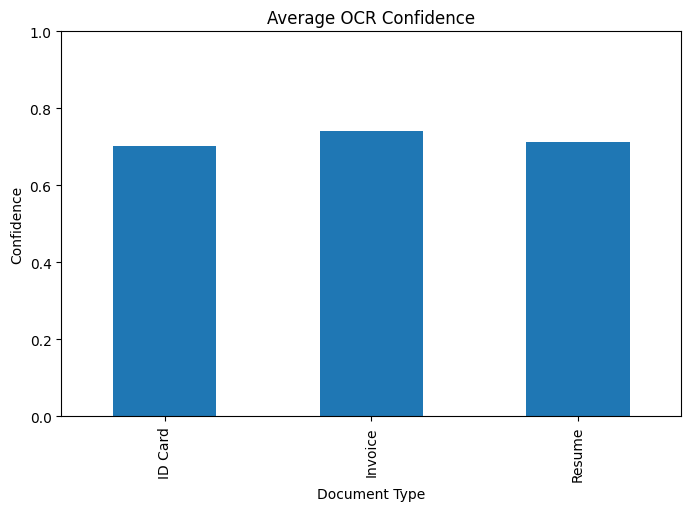

In [49]:
confidence_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average OCR Confidence")
plt.ylabel("Confidence")
plt.xlabel("Document Type")
plt.ylim(0, 1)

plt.show()

In [50]:
# Check saved OCR files

for folder in [
    OCR_OUTPUT_PATH / "invoices",
    OCR_OUTPUT_PATH / "resumes",
    OCR_OUTPUT_PATH / "id_cards"
]:
    print(f"\n{folder}")

    files = list(folder.glob("*.txt"))

    print("TXT files:", len(files))


/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/ocr/invoices
TXT files: 3

/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/ocr/resumes
TXT files: 2

/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/ocr/id_cards
TXT files: 3


In [51]:
sample_txt = list(
    (OCR_OUTPUT_PATH / "invoices").glob("*.txt")
)[0]

with open(
    sample_txt,
    "r",
    encoding="utf-8"
) as file:
    text = file.read()

print(text)

tan woon yann
BOOK TA _K (TAMAN DAYA) SDN BHD
789H17-W
NO.S: 55,57 & S9, JALAN SAGU I8,
TAMAN DAYA,
81100 JOIIOR BAHRU,
JOHOR
HHE
Dociinent No
Dale
25/12p2018 8: 13.39 PM
Cashier
MANIS
Menxler
CASH BILL
CODE/DESc
Disc
Abl( J J!l
QTY
Ri
RM
1 PC
9.00)
0,C0
9.00
Total
S
Rour :ling Acljustnienl;
0.00
Round:d Total (RM):
Cash
CHIANGE
0o
EXCH INNIGEABLE
# #ii i &
THANK YOU
PLEASE COI 'E AGATN


In [52]:
sample_txt = list(
    (OCR_OUTPUT_PATH / "resumes").glob("*.txt")
)[0]

with open(
    sample_txt,
    "r",
    encoding="utf-8"
) as file:
    text = file.read()

print(text)

Diana Dawa
b
4
WORK BPERIENCE
GENERAL SKILLS
Data Sdendtt
TECHNICAL SKILLS
dr
THETA Filrck G:ol?
CERTIFICATES
td
Mukaa
EDUCATION
Let
INTERESTS
noyorojumc.com


In [53]:
sample_txt = list(
    (OCR_OUTPUT_PATH / "id_cards").glob("*.txt")
)[0]

with open(
    sample_txt,
    "r",
    encoding="utf-8"
) as file:
    text = file.read()

print(text)

NNCOHE TAXDEPAMHENT
GOVT OF NNDIA
MONIKA MAHADEV SHINDE
MAHADEv SHINDE
31/10/1992
Pcrmpnonk Accounl Numbcr
EJAPSO276M
Slgnaluro


In [54]:
# Check OCR quality

print(ocr_summary)

  document_type                                           filename  \
0       Invoice                                   X00016469612.jpg   
1       Invoice                                   X00016469620.jpg   
2       Invoice                                   X00016469622.jpg   
3        Resume                                        Image_1.jpg   
4        Resume                                        Image_1.png   
5        Resume                                       Image_10.jpg   
6       ID Card  0005_jpeg_jpg.rf.252590ac8ae7f0f84a08f15a164d6...   
7       ID Card  0521_adhar_jpg.rf.0188ba6593c38a70e56de2509a24...   
8       ID Card  0521_adhar_jpg.rf.0b52a68eba1d0f3ea5d868a66390...   

   characters  words  detections  average_confidence  
0         389     74          37            0.715794  
1         708    136          78            0.761588  
2         472     78          53            0.743643  
3         149     18          13            0.820348  
4         157     23    